<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/binary_cross_entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [3]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (21892, 188)


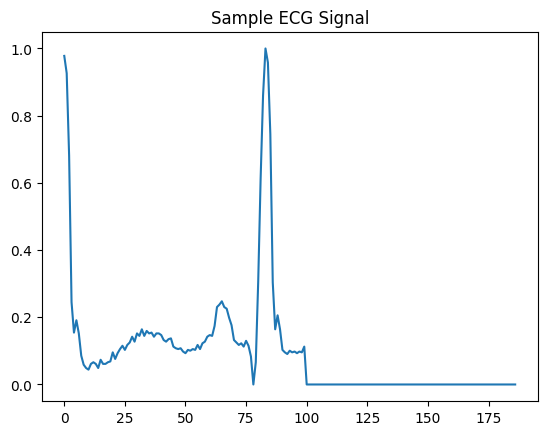

In [4]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

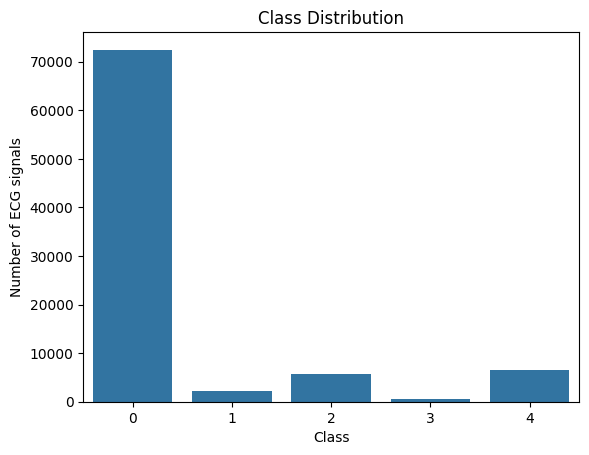

In [5]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [6]:
print("Missing values train:",train.isna().sum().sum())
print("Missing values test:",test.isna().sum().sum())

Missing values train: 0
Missing values test: 0


In [7]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [8]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [9]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [10]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [11]:
def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [13]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 372s 97ms/step - accuracy: 0.9413 - loss: 0.0656
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 374s 95ms/step - accuracy: 0.9783 - loss: 0.0259
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 354s 94ms/step - accuracy: 0.9849 - loss: 0.0184
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 353s 93ms/step - accuracy: 0.9886 - loss: 0.0142
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 391s 96ms/step - accuracy: 0.9906 - loss: 0.0117

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 382s 100ms/step - accuracy: 0.9387 - loss: 0.0675
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 376s 98ms/step - accuracy: 0.9768 - loss: 0.0277
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 371s 98ms/step - accuracy: 0.9846 - loss: 0.0191
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 381s 98ms/step - accuracy: 0.9880 - loss: 0.0149
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 367s 97ms/step - accuracy: 0.9887 - loss: 0.0137

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 382s 100ms/step - accuracy: 0.9369

In [14]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [15]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 488s 107ms/step - accuracy: 0.9412 - loss: 0.0642 - val_accuracy: 0.5773 - val_loss: 1.0257
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 465s 103ms/step - accuracy: 0.9793 - loss: 0.0252 - val_accuracy: 0.7766 - val_loss: 0.3831
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 506s 104ms/step - accuracy: 0.9856 - loss: 0.0179 - val_accuracy: 0.9194 - val_loss: 0.1026
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 510s 105ms/step - accuracy: 0.9885 - loss: 0.0143 - val_accuracy: 0.9848 - val_loss: 0.0189
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 506s 112ms/step - accuracy: 0.9908 - loss: 0.0119 - val_accuracy: 0.9905 - val_loss: 0.0122
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 490s 108ms/step - accuracy: 0.9922 - loss: 0.0101 - val_accuracy: 0.9593 - val_loss: 0.0486
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 467s 103ms/step - accuracy: 0.9931 - loss: 0.0091 - val_accuracy: 0.9891 - val_loss: 0.0138
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 485s 107ms/step - ac

In [16]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

val_mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step
Validation MCC: 0.9663974665957447


Final Training Accuracy: 0.9950911402702332
Final Validation Accuracy: 0.9728167057037354


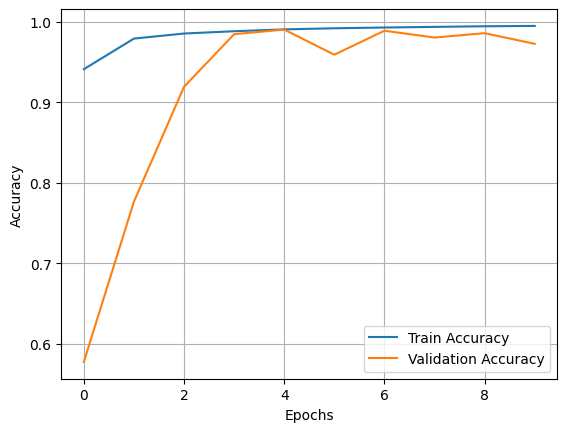

In [17]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Final Training Loss: 0.006481862161308527
Final Validation Loss: 0.041916873306035995


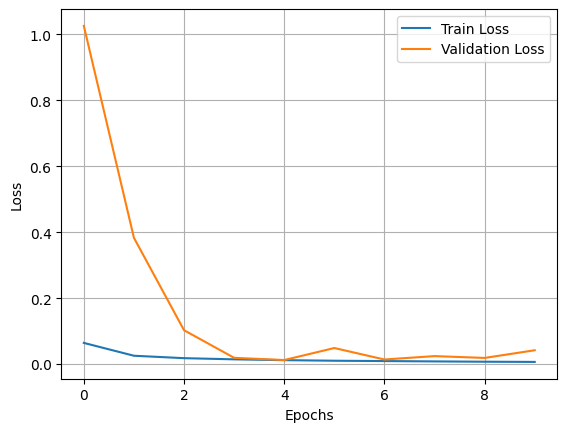

In [18]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.040186867117881775
Test Accuracy: 0.9798099994659424
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99     18118
         1.0       0.86      0.67      0.76       556
         2.0       0.96      0.95      0.96      1448
         3.0       0.89      0.59      0.71       162
         4.0       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.94      0.84      0.88     21892
weighted avg       0.98      0.98      0.98     21892



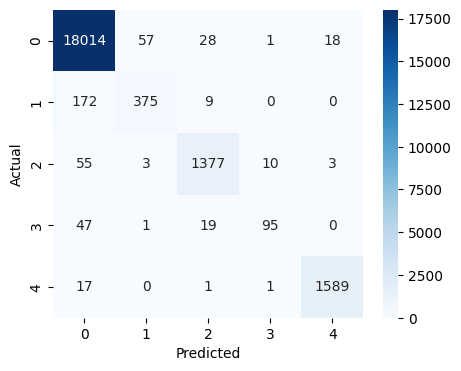

In [20]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()